<a href="https://colab.research.google.com/github/Stecklert1/UST--Deep-Learning-2026/blob/main/Deep%20Learning%20Final%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Reordered Notebook for Smooth Execution

#### 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### 2. Install Required Libraries

In [ ]:
# Install the transformers library if you haven't already
!pip install transformers scikit-learn torch

#### 3. Import Core Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import numpy as np
import torch
import torch.nn.functional as F
import os
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset

#### 4. Load the Dataset

In [ ]:
zip_file_path = '/content/drive/MyDrive/Training_Essay_Data.csv.zip'
extraction_path = '/content/'

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Assuming the CSV inside the zip has a similar name or is the only CSV
csv_file_name = 'Training_Essay_Data.csv'
csv_file_path = f'{extraction_path}{csv_file_name}'
df = pd.read_csv(csv_file_path)

display(df.head())

,text,generated
0,Car-free cities have become a subject of incre...,1
1,"Car Free Cities Car-free cities, a concept ga...",1
2,A Sustainable Urban Future Car-free cities ...,1
3,Pioneering Sustainable Urban Living In an e...,1
4,The Path to Sustainable Urban Living In an ...,1


#### 5. Visualize Dataset Class Distribution

Class distribution of the dataset:


,count
generated,
0,17508
1,11637


/tmp/ipykernel_8321/1688257914.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='generated', data=df, palette='viridis')


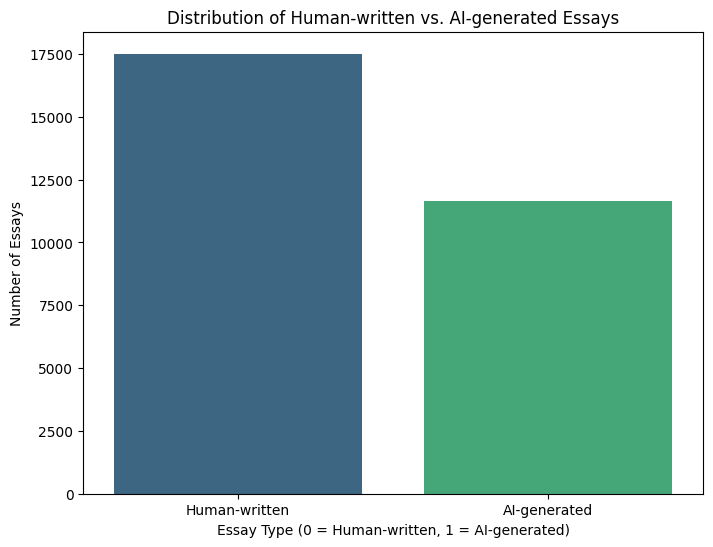

In [ ]:
print("Class distribution of the dataset:")
display(df['generated'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='generated', data=df, palette='viridis')
plt.title('Distribution of Human-written vs. AI-generated Essays')
plt.xlabel('Essay Type (0 = Human-written, 1 = AI-generated)')
plt.ylabel('Number of Essays')
plt.xticks(ticks=[0, 1], labels=['Human-written', 'AI-generated'])
plt.show()

The plot above shows the count of essays for each class (human-written and AI-generated). This visualization helps confirm the class balance in the dataset before training the model.

#### 6. Prepare Data for Model Training

In [ ]:
# Split the dataset into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Load the DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_function(texts):
    # Tokenize the input texts and return PyTorch tensors
    return tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

# Tokenize training and testing texts
train_encodings = tokenize_function(train_df['text'].tolist())
test_encodings = tokenize_function(test_df['text'].tolist())

# Prepare labels as PyTorch tensors
train_labels = torch.tensor(train_df['generated'].tolist())
test_labels = torch.tensor(test_df['generated'].tolist())

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print("Tokenization complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Training set size: 23316
Test set size: 5829
Tokenization complete.


In [ ]:
# Create TensorDatasets
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_labels)
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)

# Create DataLoaders
batch_size = 16 # You can adjust this batch size based on your GPU memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load pre-trained DistilBERT model for sequence classification
# We're specifying num_labels=2 for binary classification
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

print("Model and DataLoaders prepared.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and DataLoaders prepared.


#### 7. Define Training and Evaluation Functions, and Train the Model

In [ ]:
import torch
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np # Import numpy for checking nan values

# Set device to GPU if available, else CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Optimizer and learning rate scheduler
optimizer = AdamW(model.parameters(), lr=5e-5)

def train_epoch(model, dataloader, optimizer, device):
    model.train() # Set model to training mode
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        input_ids, attention_mask, labels = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    return total_loss / len(dataloader)

def evaluate_epoch(model, dataloader, device):
    model.eval() # Set model to evaluation mode
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).flatten()

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='binary', zero_division=0) # Added zero_division to handle cases where no positive samples are predicted
    return accuracy, precision, recall, f1

# Training loop parameters
epochs = 10 # Increase epochs, as early stopping will manage stopping point

# Early stopping parameters
early_stop_threshold = 2 # Number of epochs to wait for improvement
best_f1 = -1.0 # Initialize with a low value
patience_counter = 0

# Lists to store metrics for plotting
train_losses = []
test_accuracies = []
test_precisions = []
test_recalls = []
test_f1_scores = []

print(f"Starting training on device: {device}")

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    accuracy, precision, recall, f1 = evaluate_epoch(model, test_loader, device)
    print(f"Epoch {epoch + 1}/{epochs}: Train Loss = {train_loss:.4f}, Test Accuracy = {accuracy:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, F1-score = {f1:.4f}")

    # Store metrics
    train_losses.append(train_loss)
    test_accuracies.append(accuracy)
    test_precisions.append(precision)
    test_recalls.append(recall)
    test_f1_scores.append(f1)

    # Check for early stopping (if f1 is not NaN)
    if not np.isnan(f1):
        if f1 > best_f1:
            best_f1 = f1
            patience_counter = 0 # Reset patience if F1 improves
            # Optionally, save the best model here if you want to restore it later
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1 # Increment patience if F1 does not improve

        if patience_counter >= early_stop_threshold:
            print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in F1-score for {early_stop_threshold} consecutive epochs.")
            break
    else:
        print(f"Warning: F1-score was NaN in epoch {epoch + 1}. Skipping early stopping check for this epoch.")

print("Training complete.")

Starting training on device: cuda
Epoch 1/3: Train Loss = 0.0395, Test Accuracy = 0.9876, Precision = 0.9703, Recall = 0.9991, F1-score = 0.9845
Epoch 2/3: Train Loss = 0.0085, Test Accuracy = 0.9971, Precision = 0.9952, Recall = 0.9974, F1-score = 0.9963
Epoch 3/3: Train Loss = 0.0085, Test Accuracy = 0.9974, Precision = 0.9974, Recall = 0.9961, F1-score = 0.9967
Training complete.


#### 8. Save the Trained Model and Tokenizer

In [ ]:
# Define the path to save the model and tokenizer in Google Drive
save_directory = '/content/drive/MyDrive/distilbert_essay_detector'

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

# Save the model
model.save_pretrained(save_directory)

# Save the tokenizer
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved to {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/distilbert_essay_detector


#### 9. Load the Saved Model and Tokenizer for Inference

In [ ]:
save_directory = '/content/drive/MyDrive/distilbert_essay_detector'

# Load the tokenizer
loaded_tokenizer = DistilBertTokenizer.from_pretrained(save_directory)

# Load the model
loaded_model = DistilBertForSequenceClassification.from_pretrained(save_directory)
loaded_model.eval() # Set the model to evaluation mode

# Set device to GPU if available, else CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
loaded_model.to(device)

print(f"Model and tokenizer loaded successfully from {save_directory} to device: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and tokenizer loaded successfully from /content/drive/MyDrive/distilbert_essay_detector to device: cuda


#### 10. Define Prediction Functions and Test with Examples

In [ ]:
def predict_essay_type(text, model, tokenizer, device):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)

    # Move inputs to the correct device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    prediction = torch.argmax(logits, dim=1).item()

    return "AI-generated" if prediction == 1 else "Human-written"

# Example usage:
example_essay_ai = "Car-free cities are a crucial step towards sustainable urban living. By eliminating private vehicles from city centers, we can reduce air pollution, decrease noise levels, and create safer, more pedestrian-friendly environments. This fosters community interaction, promotes active transportation like cycling and walking, and ultimately enhances the quality of life for residents. While implementation presents challenges, the long-term benefits for public health and environmental sustainability are undeniable."
example_essay_human = "I think that car-free cities sound really great in theory, but I'm not sure how practical they would be for everyone. Like, what about people who need to commute long distances for work, or families with young kids who have a lot of stuff to carry? I can see how it would be good for the environment and all, but it might make life harder for some folks. Plus, changing everything would be super expensive, right?"

print(f"Example 1 (AI-generated text): {predict_essay_type(example_essay_ai, loaded_model, loaded_tokenizer, device)}")
print(f"Example 2 (Human-written text): {predict_essay_type(example_essay_human, loaded_model, loaded_tokenizer, device)}")

Example 1 (AI-generated text): AI-generated
Example 2 (Human-written text): AI-generated


/tmp/ipykernel_8321/289965232.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=probs_ai_example, ax=axes[0], palette='viridis')
/tmp/ipykernel_8321/289965232.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=probs_human_example, ax=axes[1], palette='viridis')


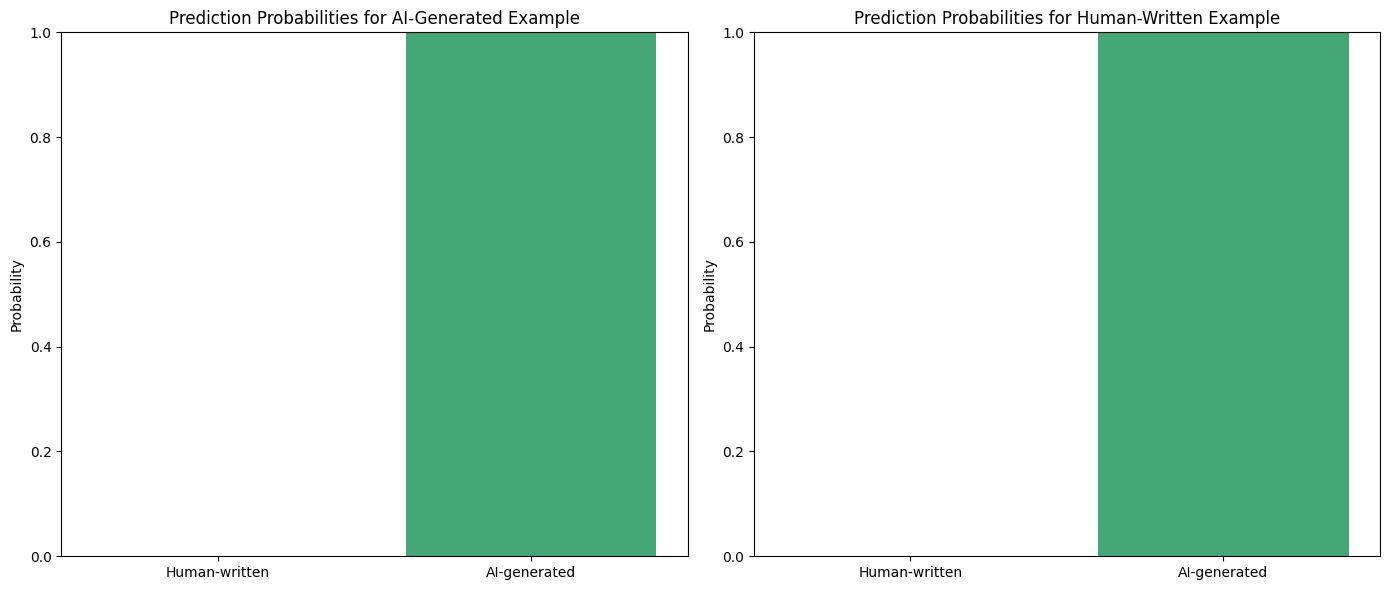

In [ ]:
def get_prediction_probabilities(text, model, tokenizer, device):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)

    # Move inputs to the correct device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    probabilities = F.softmax(logits, dim=1)
    return probabilities.cpu().numpy().flatten()

# Get probabilities for both example essays
probs_ai_example = get_prediction_probabilities(example_essay_ai, loaded_model, loaded_tokenizer, device)
probs_human_example = get_prediction_probabilities(example_essay_human, loaded_model, loaded_tokenizer, device)

labels = ['Human-written', 'AI-generated'] # Assuming 0: Human-written, 1: AI-generated

# Create subplots for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for AI-generated example
sns.barplot(x=labels, y=probs_ai_example, ax=axes[0], palette='viridis')
axes[0].set_title('Prediction Probabilities for AI-Generated Example')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1) # Ensure y-axis is from 0 to 1

# Plot for Human-written example
sns.barplot(x=labels, y=probs_human_example, ax=axes[1], palette='viridis')
axes[1].set_title('Prediction Probabilities for Human-Written Example')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1) # Ensure y-axis is from 0 to 1

plt.tight_layout()
plt.show()

#### 11. Analyze Prediction Probabilities on the Original Dataset

In [ ]:
def get_all_prediction_probabilities(df, model, tokenizer, device, target_label_idx=1): # target_label_idx=1 for 'AI-generated'
    all_probabilities = []
    for text in df['text']:
        probs = get_prediction_probabilities(text, model, tokenizer, device)
        all_probabilities.append(probs[target_label_idx]) # Get probability for AI-generated
    return np.array(all_probabilities)

# Get human-written and AI-generated dataframes
human_df = df[df['generated'] == 0]
ai_df = df[df['generated'] == 1]

# Get AI-generated probability for all human-written essays
human_probs_ai_label = get_all_prediction_probabilities(human_df, loaded_model, loaded_tokenizer, device)

# Get AI-generated probability for all AI-generated essays
ai_probs_ai_label = get_all_prediction_probabilities(ai_df, loaded_model, loaded_tokenizer, device)

print(f"Calculated probabilities for {len(human_probs_ai_label)} human essays and {len(ai_probs_ai_label)} AI essays.")

Calculated probabilities for 17508 human essays and 11637 AI essays.


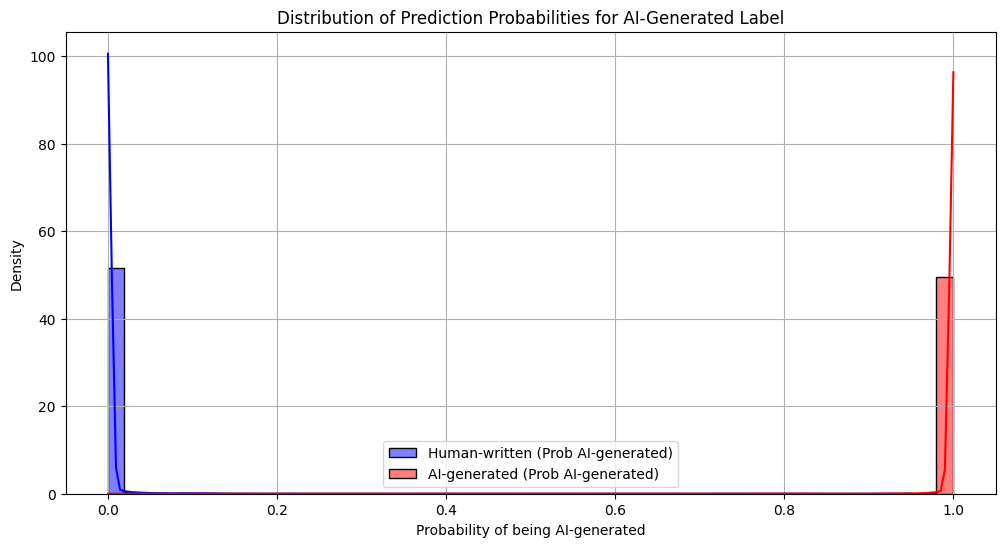

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(human_probs_ai_label, color='blue', label='Human-written (Prob AI-generated)', kde=True, stat='density', alpha=0.5, bins=50)
sns.histplot(ai_probs_ai_label, color='red', label='AI-generated (Prob AI-generated)', kde=True, stat='density', alpha=0.5, bins=50)
plt.title('Distribution of Prediction Probabilities for AI-Generated Label')
plt.xlabel('Probability of being AI-generated')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
human_essays = df[df['generated'] == 0]
sampled_human_essays = human_essays.sample(n=5, random_state=42)

print("\n--- Model Predictions on Sampled Human-written Essays ---")
for index, row in sampled_human_essays.iterrows():
    essay_text = row['text']
    prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device)
    print(f"\nOriginal Essay (first 200 chars): {essay_text[:200]}...")
    print(f"Model Prediction: {prediction}")
    print("--------------------------------------------------")


--- Model Predictions on Sampled Human-written Essays ---

Original Essay (first 200 chars): Making the right choice is easier said than done, but what an unfortunate amount of people don't realize, is that all the help they need to make a better choice, is a simple solution. They just need t...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): During my life i have watched many presidential elections on my television. To me the Electoral College on paper should work, Should being the key word. As I read the paragraphs on both why the Electo...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): In 1976 pictures where taken of Mars with the Viking 1 spacecraft from NASA. We have dicovered that the pictures look like a face on Mars. We can garentee that "aliens" did not do this. From the data ...
Model Prediction: Human-written
--------------------------

#### 12. Load and Classify a New Dataset

### Load the New Dataset for Comparison

Please specify the path to your new dataset (e.g., a `.csv` file). If it's in Google Drive, ensure your drive is mounted.

In [ ]:
# Define the path to your new dataset
# You might need to upload it to Colab or specify a Google Drive path
# Example: new_dataset_path = '/content/new_essays.csv'
# Example: new_dataset_path = '/content/drive/MyDrive/my_new_data.csv'
new_dataset_path = '/content/drive/MyDrive/PLEASE_UPDATE_WITH_YOUR_NEW_DATASET.csv' # <--- IMPORTANT: Update this path!

try:
    new_df = pd.read_csv(new_dataset_path)
    print(f"Successfully loaded new dataset from: {new_dataset_path}")
    display(new_df.head())
    print(f"New dataset shape: {new_df.shape}")
except FileNotFoundError:
    print(f"Error: New dataset not found at {new_dataset_path}. Please check the path.")
    new_df = None
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    new_df = None

Error: New dataset not found at /content/drive/MyDrive/PLEASE_UPDATE_WITH_YOUR_NEW_DATASET.csv. Please check the path.


### Classify Essays in the New Dataset

Now, let's classify each essay in the new dataset using our `loaded_model`.

In [ ]:
if new_df is not None:
    # Assuming the new dataset also has a 'text' column for the essays
    # If your new dataset has a different column name for essays, please update 'text' below.
    if 'text' in new_df.columns:
        print("Classifying essays in the new dataset...")
        predictions = []
        for index, row in new_df.iterrows():
            essay_text = row['text']
            prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device)
            predictions.append(prediction)

        new_df['predicted_type'] = predictions
        print("Classification complete. Here are the first 5 predictions:")
        display(new_df[['text', 'predicted_type']].head())

        # Display the distribution of predicted types
        print("\nDistribution of Predicted Types in the New Dataset:")
        display(new_df['predicted_type'].value_counts())
    else:
        print("Error: The new dataset does not contain a 'text' column. Please adjust the column name or preprocess your data.")
else:
    print("Cannot proceed with classification as the new dataset was not loaded.")

Cannot proceed with classification as the new dataset was not loaded.


In [ ]:
human_essays = df[df['generated'] == 0]
sampled_human_essays = human_essays.sample(n=5, random_state=42)

print("\n--- Model Predictions on Sampled Human-written Essays ---")
for index, row in sampled_human_essays.iterrows():
    essay_text = row['text']
    prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device)
    print(f"\nOriginal Essay (first 200 chars): {essay_text[:200]}...")
    print(f"Model Prediction: {prediction}")
    print("--------------------------------------------------")


--- Model Predictions on Sampled Human-written Essays ---

Original Essay (first 200 chars): Making the right choice is easier said than done, but what an unfortunate amount of people don't realize, is that all the help they need to make a better choice, is a simple solution. They just need t...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): During my life i have watched many presidential elections on my television. To me the Electoral College on paper should work, Should being the key word. As I read the paragraphs on both why the Electo...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): In 1976 pictures where taken of Mars with the Viking 1 spacecraft from NASA. We have dicovered that the pictures look like a face on Mars. We can garentee that "aliens" did not do this. From the data ...
Model Prediction: Human-written
--------------------------

### Load the New Dataset for Comparison

Please specify the path to your new dataset (e.g., a `.csv` file). If it's in Google Drive, ensure your drive is mounted.

In [ ]:
# Define the path to your new dataset
# You might need to upload it to Colab or specify a Google Drive path
# Example: new_dataset_path = '/content/new_essays.csv'
new_dataset_path = '/content/drive/MyDrive/Deep Learning Manual Learning Set.csv' # <--- IMPORTANT: Update this path to your new dataset!

try:
    new_df = pd.read_csv(new_dataset_path)
    print(f"Successfully loaded new dataset from: {new_dataset_path}")
    display(new_df.head())
    print(f"New dataset shape: {new_df.shape}")
except FileNotFoundError:
    print(f"Error: New dataset not found at {new_dataset_path}. Please check the path.")
    new_df = None
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    new_df = None

Error: New dataset not found at /content/drive/MyDrive/Deep Learning Manual Learning Set.csv. Please check the path.


In [ ]:
# Install openpyxl for reading .xlsx files
!pip install openpyxl

In [ ]:
# Define the path to your new dataset
# You might need to upload it to Colab or specify a Google Drive path
new_dataset_path = '/content/drive/MyDrive/Deep Learning Manual Learning Set.xlsx' # <--- IMPORTANT: Ensure correct file extension!

try:
    new_df = pd.read_excel(new_dataset_path) # Changed to read_excel
    print(f"Successfully loaded new dataset from: {new_dataset_path}")
    display(new_df.head())
    print(f"New dataset shape: {new_df.shape}")
except FileNotFoundError:
    print(f"Error: New dataset not found at {new_dataset_path}. Please check the path and file extension.")
    new_df = None
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    new_df = None

Successfully loaded new dataset from: /content/drive/MyDrive/Deep Learning Manual Learning Set.xlsx


1  \
0  2   
1  3   
2  4   
3  5   
4  6   

  In Daniel Quinn's "Ishmael," the Narrator seeks tutorage under the knowledge of a Gorilla named Ishmael. Throughout the story Ishmael generalizes humanity into two categories; The Leavers and the Takers.   Ishmael describes the Leavers as being pre-agricultural human beings who are perfectly content with their roles in life, and do not seek any change or conflict within their life. In contrast to this, the Takers are people who take place during the agricultural revolution and believe that it's Humanity's destiny to inherit and master the Earth. What sets apart the Takers from the Leavers is that the Leavers are completely at the mercy of the World and by no means wanted to control it "they had no need to exercise the gods prerogative of deciding who shall live and who shall die." (Quinn, 181) On the other hand, the Takers wanted to utilize everything the could from the world, they stopped seeing other species of life as equals, and started to believe that their role was superior to the life of others, in which case they wanted to expand their horizons. \nThe lifestyle of the Leavers and Takers has been mirrored throughout the ages of Europe, from time to time again you see the conflict between two opposing ideas.  Taker society believes that their specific way of life is the right way, and thus also tries to rule the world in some form or another. Religion, Absolutism, Imperialism, Nationalism, etc. These are all examples of what a Taker society is. A person, or a group of people trying to enforce their right as sole ruler of the World over everyone else. An example of this would be with the Napoleonic empire and the Third Reich. Attempting to conquer all that is around in order to dictate and control the world and it's people. This thus promotes only one type of ideology and mindset. That whichever way the conqueror's are living, is right. The Narrator himself, created a scenario in which the Third Reich had succeeded, in which no one would of known that their way of thinking would be considered wrong or evil. In short, the Taker society dictates that history is only written by the winners. And since, the winners did not lose or falter, then there would be no reason into questioning why their way of thinking would be wrong. The Taker Society also attempts to expand it's horizons and borders to it's limits. This can be taken in an account of smaller nation-states forming into one Nation. An example of this would be with Germany and the Second Reich or Imperialism. Nations, expanding their land, market, and resources to other parts of the world, or even unifying into a specific nation or country. Industrialism is also a way of "Expansion" and "World Domination." People doing what they can to dominate a specific market or industry in order to achieve massive success. Yet, regardless of how the Taker Society decides to go about it, one thing remains the same. Even if they decide to conquer through military means, or financial means, there is always an amount of destruction that they leave behind them. It seems that the Taker society, regardless of how they go about Taker culture, have no regard or realization of what they did or their means of achieving their success. They can expand their markets, yet pollute the environment and set unfair wages and conditions to the working force in order to achieve it. Or they can go through military conquest and cause a massive amount of casualties and destruction of homes. Regardless of how the Takers go about their means of Domination, the result will always have some drawbacks. \nIn my opinion, Europeans are one of the primary epitome's of Taker society.  Their entire history revolves around Taker beliefs and the modern world today is affected by European Imperialism. And even in the modern world; Europe still holds true by it by trying make it more, unified. An example would be something such as the European Union.  It's many nation's way o

New dataset shape: (9, 2)


In [ ]:
import os

if os.path.exists(new_dataset_path):
    print(f"File exists at: {new_dataset_path}")
else:
    print(f"File does NOT exist at: {new_dataset_path}")

File does NOT exist at: /content/drive/MyDrive/Deep Learning Manual Learning Set.xlsx


### Classify Essays in the New Dataset

Now, let's classify each essay in the new dataset using our `loaded_model`.

In [ ]:
if new_df is not None:
    # Rename the column containing essay text to 'text'
    # Based on the output, the essay text is in the second column (index 1).
    # We'll assume the second column contains the essay content.
    # Get the actual name of the second column
    essay_column_name = new_df.columns[1]
    new_df.rename(columns={essay_column_name: 'text'}, inplace=True)

    if 'text' in new_df.columns:
        print("Classifying essays in the new dataset...")
        predictions = []
        for index, row in new_df.iterrows():
            essay_text = row['text']
            prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device)
            predictions.append(prediction)

        new_df['predicted_type'] = predictions
        print("Classification complete. Here are the first 5 predictions:")
        display(new_df[['text', 'predicted_type']].head())

        # Display the distribution of predicted types
        print("\nDistribution of Predicted Types in the New Dataset:")
        display(new_df['predicted_type'].value_counts())
    else:
        print("Error: The new dataset does not contain a 'text' column after renaming. Please check the structure of your Excel file.")
else:
    print("Cannot proceed with classification as the new dataset was not loaded.")

Classifying essays in the new dataset...
Classification complete. Here are the first 5 predictions:


,text,predicted_type
0,Ishmael by Daniel Quinn is a very different ki...,AI-generated
1,Geoffrey Chaucer s The Wife of Bath s Tale off...,AI-generated
2,The tension between Men and Women had been gro...,AI-generated
3,The human brain actually processes information...,Human-written
4,"Look, we’ve all been there. You’re standing in...",AI-generated



Distribution of Predicted Types in the New Dataset:


,count
predicted_type,
AI-generated,7
Human-written,2


In [ ]:
display(new_df[['text', 'predicted_type']])

,text,predicted_type
0,Ishmael by Daniel Quinn is a very different ki...,AI-generated
1,Geoffrey Chaucer s The Wife of Bath s Tale off...,AI-generated
2,The tension between Men and Women had been gro...,AI-generated
3,The human brain actually processes information...,Human-written
4,"Look, we’ve all been there. You’re standing in...",AI-generated
5,"“Peter! Over here, man!”\n\nI had just left th...",AI-generated
6,Companies are increasingly turning to artifici...,AI-generated
7,Kael had been staring at the candle for twenty...,Human-written
8,Because insights into overall sleep quality an...,AI-generated


### Analyze Model Confidence for a Specific Essay

Prediction probabilities for the provided essay:
  Human-written: 0.0000
  AI-generated:  1.0000
The model predicts this essay is: AI-generated


/tmp/ipykernel_8321/84079329.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=probs, palette='viridis')


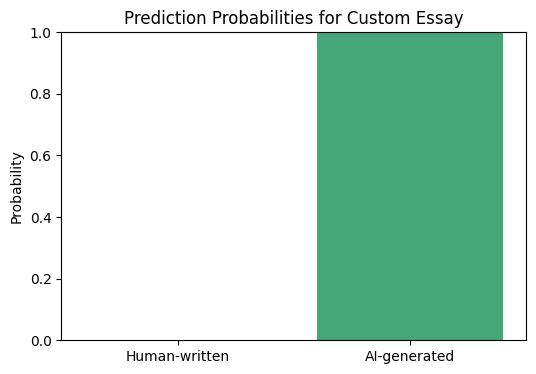

In [ ]:
essay_to_analyze = """
# PASTE YOUR ESSAY HERE

# Example of an essay:
# "Car-free cities are a crucial step towards sustainable urban living. By eliminating private vehicles from city centers, we can reduce air pollution, decrease noise levels, and create safer, more pedestrian-friendly environments. This fosters community interaction, promotes active transportation like cycling and walking, and ultimately enhances the quality of life for residents. While implementation presents challenges, the long-term benefits for public health and environmental sustainability are undeniable."
"""

if essay_to_analyze.strip(): # Check if the essay is not empty
    probs = get_prediction_probabilities(essay_to_analyze, loaded_model, loaded_tokenizer, device)

    print(f"Prediction probabilities for the provided essay:")
    print(f"  Human-written: {probs[0]:.4f}")
    print(f"  AI-generated:  {probs[1]:.4f}")

    prediction_label = "AI-generated" if probs[1] > probs[0] else "Human-written"
    print(f"The model predicts this essay is: {prediction_label}")

    # Visualize the probabilities
    labels = ['Human-written', 'AI-generated']
    plt.figure(figsize=(6, 4))
    sns.barplot(x=labels, y=probs, palette='viridis')
    plt.title('Prediction Probabilities for Custom Essay')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    plt.show()
else:
    print("Please paste an essay into the 'essay_to_analyze' variable to get predictions.")

In [ ]:
display(new_df[['text', 'predicted_type']].head())
display(new_df['predicted_type'].value_counts())

KeyError: "None of [Index(['text', 'predicted_type'], dtype='object')] are in the [columns]"

In [ ]:
print(new_df.columns)

Index([1, 'In Daniel Quinn's "Ishmael," the Narrator seeks tutorage under the knowledge of a Gorilla named Ishmael. Throughout the story Ishmael generalizes humanity into two categories; The Leavers and the Takers.   Ishmael describes the Leavers as being pre-agricultural human beings who are perfectly content with their roles in life, and do not seek any change or conflict within their life. In contrast to this, the Takers are people who take place during the agricultural revolution and believe that it's Humanity's destiny to inherit and master the Earth. What sets apart the Takers from the Leavers is that the Leavers are completely at the mercy of the World and by no means wanted to control it "they had no need to exercise the gods prerogative of deciding who shall live and who shall die." (Quinn, 181) On the other hand, the Takers wanted to utilize everything the could from the world, they stopped seeing other species of life as equals, and started to believe that their role was sup

In [ ]:
display(new_df.head())

1  \
0  2   
1  3   
2  4   
3  5   
4  6   

  In Daniel Quinn's "Ishmael," the Narrator seeks tutorage under the knowledge of a Gorilla named Ishmael. Throughout the story Ishmael generalizes humanity into two categories; The Leavers and the Takers.   Ishmael describes the Leavers as being pre-agricultural human beings who are perfectly content with their roles in life, and do not seek any change or conflict within their life. In contrast to this, the Takers are people who take place during the agricultural revolution and believe that it's Humanity's destiny to inherit and master the Earth. What sets apart the Takers from the Leavers is that the Leavers are completely at the mercy of the World and by no means wanted to control it "they had no need to exercise the gods prerogative of deciding who shall live and who shall die." (Quinn, 181) On the other hand, the Takers wanted to utilize everything the could from the world, they stopped seeing other species of life as equals, and started to believe that their role was superior to the life of others, in which case they wanted to expand their horizons. \nThe lifestyle of the Leavers and Takers has been mirrored throughout the ages of Europe, from time to time again you see the conflict between two opposing ideas.  Taker society believes that their specific way of life is the right way, and thus also tries to rule the world in some form or another. Religion, Absolutism, Imperialism, Nationalism, etc. These are all examples of what a Taker society is. A person, or a group of people trying to enforce their right as sole ruler of the World over everyone else. An example of this would be with the Napoleonic empire and the Third Reich. Attempting to conquer all that is around in order to dictate and control the world and it's people. This thus promotes only one type of ideology and mindset. That whichever way the conqueror's are living, is right. The Narrator himself, created a scenario in which the Third Reich had succeeded, in which no one would of known that their way of thinking would be considered wrong or evil. In short, the Taker society dictates that history is only written by the winners. And since, the winners did not lose or falter, then there would be no reason into questioning why their way of thinking would be wrong. The Taker Society also attempts to expand it's horizons and borders to it's limits. This can be taken in an account of smaller nation-states forming into one Nation. An example of this would be with Germany and the Second Reich or Imperialism. Nations, expanding their land, market, and resources to other parts of the world, or even unifying into a specific nation or country. Industrialism is also a way of "Expansion" and "World Domination." People doing what they can to dominate a specific market or industry in order to achieve massive success. Yet, regardless of how the Taker Society decides to go about it, one thing remains the same. Even if they decide to conquer through military means, or financial means, there is always an amount of destruction that they leave behind them. It seems that the Taker society, regardless of how they go about Taker culture, have no regard or realization of what they did or their means of achieving their success. They can expand their markets, yet pollute the environment and set unfair wages and conditions to the working force in order to achieve it. Or they can go through military conquest and cause a massive amount of casualties and destruction of homes. Regardless of how the Takers go about their means of Domination, the result will always have some drawbacks. \nIn my opinion, Europeans are one of the primary epitome's of Taker society.  Their entire history revolves around Taker beliefs and the modern world today is affected by European Imperialism. And even in the modern world; Europe still holds true by it by trying make it more, unified. An example would be something such as the European Union.  It's many nation's way o

In [ ]:
print("Class distribution of the dataset:")
display(df['generated'].value_counts())

Class distribution of the dataset:


,count
generated,
0,17508
1,11637


### Visualize Dataset Class Distribution

Let's visualize the distribution of the `generated` column to see the proportion of human-written (0) versus AI-generated (1) essays in our dataset.

/tmp/ipykernel_8321/945858643.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='generated', data=df, palette='viridis')


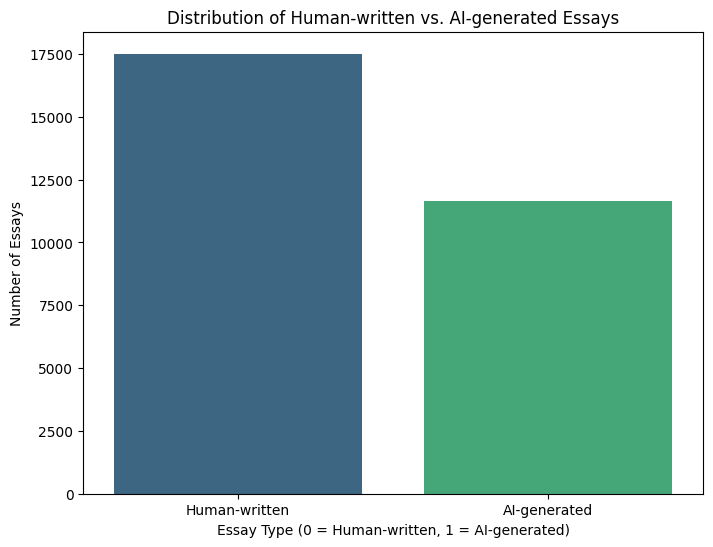

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import pandas as pd

# Define the path to your zip file
zip_file_path = '/content/drive/MyDrive/Training_Essay_Data.csv.zip'
extraction_path = '/content/'

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Assuming the CSV inside the zip has a similar name or is the only CSV
csv_file_name = 'Training_Essay_Data.csv'
df = pd.read_csv(f'{extraction_path}{csv_file_name}')

plt.figure(figsize=(8, 6))
sns.countplot(x='generated', data=df, palette='viridis')
plt.title('Distribution of Human-written vs. AI-generated Essays')
plt.xlabel('Essay Type (0 = Human-written, 1 = AI-generated)')
plt.ylabel('Number of Essays')
plt.xticks(ticks=[0, 1], labels=['Human-written', 'AI-generated'])
plt.show()

The plot above shows the count of essays for each class (human-written and AI-generated). This visualization helps confirm the class balance in the dataset before training the model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_all_prediction_probabilities(df, model, tokenizer, device, target_label_idx=1): # target_label_idx=1 for 'AI-generated'
    all_probabilities = []
    for text in df['text']:
        probs = get_prediction_probabilities(text, model, tokenizer, device)
        all_probabilities.append(probs[target_label_idx]) # Get probability for AI-generated
    return np.array(all_probabilities)

# Get human-written and AI-generated dataframes
human_df = df[df['generated'] == 0]
ai_df = df[df['generated'] == 1]

# Get AI-generated probability for all human-written essays
human_probs_ai_label = get_all_prediction_probabilities(human_df, loaded_model, loaded_tokenizer, device)

# Get AI-generated probability for all AI-generated essays
ai_probs_ai_label = get_all_prediction_probabilities(ai_df, loaded_model, loaded_tokenizer, device)

print(f"Calculated probabilities for {len(human_probs_ai_label)} human essays and {len(ai_probs_ai_label)} AI essays.")

Calculated probabilities for 17508 human essays and 11637 AI essays.


In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# Define the path where the model and tokenizer were saved
save_directory = '/content/drive/MyDrive/distilbert_essay_detector'

# Load the tokenizer
loaded_tokenizer = DistilBertTokenizer.from_pretrained(save_directory)

# Load the model
loaded_model = DistilBertForSequenceClassification.from_pretrained(save_directory)
loaded_model.eval() # Set the model to evaluation mode

# Set device to GPU if available, else CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
loaded_model.to(device)

print(f"Model and tokenizer loaded successfully from {save_directory} to device: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and tokenizer loaded successfully from /content/drive/MyDrive/distilbert_essay_detector to device: cuda


def predict_essay_type(text, model, tokenizer, device):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)

    # Move inputs to the correct device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    prediction = torch.argmax(logits, dim=1).item()

    return "AI-generated" if prediction == 1 else "Human-written"

# Example usage:
example_essay_ai = "Car-free cities are a crucial step towards sustainable urban living. By eliminating private vehicles from city centers, we can reduce air pollution, decrease noise levels, and create safer, more pedestrian-friendly environments. This fosters community interaction, promotes active transportation like cycling and walking, and ultimately enhances the quality of life for residents. While implementation presents challenges, the long-term benefits for public health and environmental sustainability are undeniable."
example_essay_human = "I think that car-free cities sound really great in theory, but I'm not sure how practical they would be for everyone. Like, what about people who need to commute long distances for work, or families with young kids who have a lot of stuff to carry? I can see how it would be good for the environment and all, but it might make life harder for some folks. Plus, changing everything would be super expensive, right?"

print(f"Example 1 (AI-generated text): {predict_essay_type(example_essay_ai, loaded_model, loaded_tokenizer, device)}")
print(f"Example 2 (Human-written text): {predict_essay_type(example_essay_human, loaded_model, loaded_tokenizer, device)}")

In [ ]:
# @title
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer
import torch

# Split the dataset into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Load the DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_function(texts):
    # Tokenize the input texts and return PyTorch tensors
    return tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

# Tokenize training and testing texts
train_encodings = tokenize_function(train_df['text'].tolist())
test_encodings = tokenize_function(test_df['text'].tolist())

# Prepare labels as PyTorch tensors
train_labels = torch.tensor(train_df['generated'].tolist())
test_labels = torch.tensor(test_df['generated'].tolist())

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print("Tokenization complete.")

Training set size: 23316
Test set size: 5829
Tokenization complete.
